<h1> <center> Telco Customer Churn Prediction using Traditional ML Classification Algorithms </center> </h1>

In [1]:
#Import required libraries:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_validate , StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder , StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier , ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline
#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

#Import the dataset:
df = pd.read_csv("dataset.csv")

In [2]:
#Inspect the dataset:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Inspect the data:
print(df.info(),end="\n\n\n\n")
print(df.isnull().sum(),end="\n\n\n\n")
print(df.describe(),end="\n\n\n\n")
print(df.duplicated().sum(),end="\n\n\n\n")
print(df.shape,end="\n\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#Inspect the target variable:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
for i in df.columns:
    print("\n\nNAME = ")
    print(df[i].value_counts())

print("\n\n\n",df.shape)



NAME = 
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64


NAME = 
gender
Male      3555
Female    3488
Name: count, dtype: int64


NAME = 
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


NAME = 
Partner
No     3641
Yes    3402
Name: count, dtype: int64


NAME = 
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


NAME = 
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


NAME = 
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


NAME = 
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


NAME = 
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


NAME

In [7]:
#Prepare the data:

cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

df[cols] = df[cols].replace("No internet service", "No")

df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


df.dropna(inplace=True)

print(df["Churn"].head(5))
df["Churn"] = df["Churn"].replace("No",0)
df["Churn"] = df["Churn"].replace("Yes",1)




0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [8]:
#Inspect the shape once again:
df.shape

(7032, 20)

**Now implement Machine Learning:**

In [9]:
X = df[["gender","tenure","Dependents",
        "SeniorCitizen","Partner",
        "InternetService","PhoneService",
        "TechSupport","Contract",
        "PaymentMethod","TotalCharges",
       "StreamingTV","StreamingMovies"]]

y = df['Churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)



num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
])


# All CLassification Pipelines:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=8, n_jobs=-1))
])



et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesClassifier(n_estimators=130, max_depth=9, n_jobs=-1,random_state=42))
])


ada_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=6),
        n_estimators=200, 
        learning_rate=0.8,
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='logloss'
    ))
])





# Cross Validation:
## Model Dictionary:

models = {
    "Logistic Regression": lr_pipeline,
    "KNN Classifier": knn_pipeline,
    "Extra Trees": et_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost": xgb_pipeline
}

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)   # Since our dataset is imbalanced.
scoring = ['accuracy', 'f1_weighted']

results = []

for name, model in models.items():
    print(f"Running {name}...")
    
    cv_results = cross_validate(
        model, 
        X_train, 
        y_train,
        cv=kf, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "CV Accuracy": round(np.mean(cv_results['test_accuracy']), 4),
        "CV F1 Score": round(np.mean(cv_results['test_f1_weighted']), 4)
    })

results_df = pd.DataFrame(results).sort_values(by="CV Accuracy", ascending=False)
print("\n" + "="*50)
print(results_df)

Running Logistic Regression...
Running KNN Classifier...
Running Extra Trees...
Running AdaBoost...
Running XGBoost...

                 Model  CV Accuracy  CV F1 Score
0  Logistic Regression       0.7984       0.7920
2          Extra Trees       0.7950       0.7866
3             AdaBoost       0.7829       0.7761
1       KNN Classifier       0.7780       0.7652
4              XGBoost       0.7737       0.7678


In [10]:
#Now make predictions using the best model:

single_data = pd.DataFrame([{
    "gender":"Male",
    "Partner":"No",
    "Dependents": "Yes",
    "SeniorCitizen": 0,
    "tenure": 22,
    "PhoneService": "Yes",
    "InternetService": "Fiber optic",
    "TechSupport": "No",
    "Contract": "Month-to-month",
    "PaymentMethod": "Credit card (automatic)",
    "TotalCharges": 1949.4,
    "StreamingTV":"Yes",
    "StreamingMovies":"No"
}])

best_model = models[results_df.iloc[0]["Model"]]
best_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'SeniorCitizen',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Dependents',
                                                   'Partner', 'InternetService',
                                                   'PhoneService',
                                                   'TechSupport', 'Contract',
                                                   'PaymentMethod',
                                                   'StreamingTV',
                                                   'StreamingMovies'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [11]:
pred = best_model.predict(single_data)

if pred==0:
    print("This customer will not churn")
else:
    print("This customer will churn")

This customer will not churn


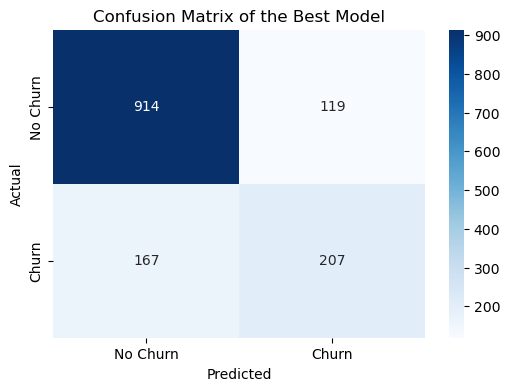

In [12]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of the Best Model")
plt.show()

In [13]:
# Classification Report
print("Classification Report of the best model:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report of the best model:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.63      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



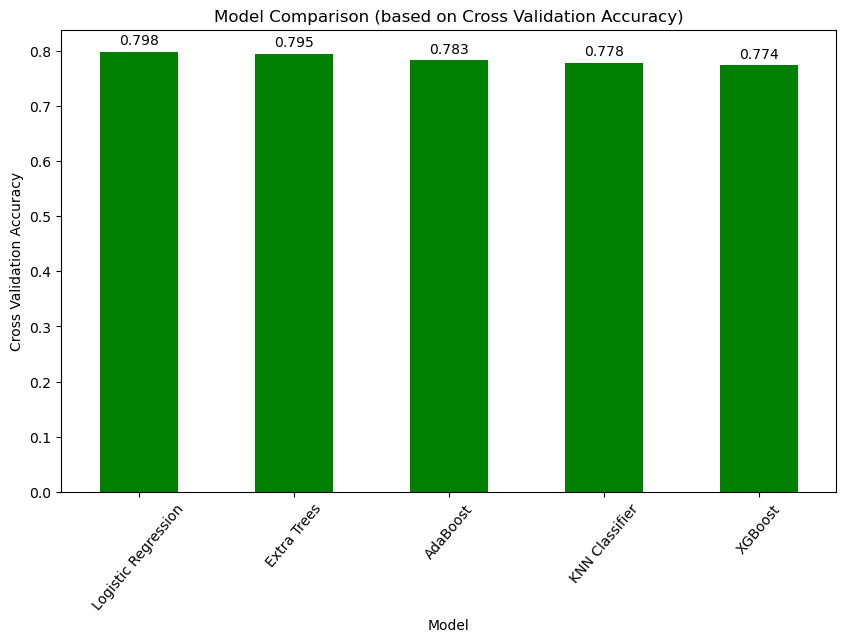

['CustomerChurnPredictionModel.pkl']

In [14]:
#Model comparison:

plt.figure(figsize=(10,6))
ax = results_df.set_index("Model")["CV Accuracy"].plot(kind='bar',color="green")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)

plt.title("Model Comparison (based on Cross Validation Accuracy)")

plt.xlabel("Model")
plt.ylabel("Cross Validation Accuracy")
plt.xticks(rotation=50)
plt.show()

#Export this model:
import joblib
joblib.dump(best_model,"CustomerChurnPredictionModel.pkl")

### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368